##  Pairs trading system with macro data + ensemble learning

To get High Returns with Low Beta (Market Neutral), we need a pair that hates each other. We need assets that move in opposite directions during stress.

We will trade the spread between Consumer Discretionary (XLY) and Consumer Staples (XLP). 


    XLY (Amazon, Tesla, Nike): Rips when the economy is booming. Dies when rates rise.

    XLP (Coke, P&G, Walmart): Boring. People buy toothpaste even during a crash. Holds value when the market tanks.


We use Macro Data (Interest Rates) + Ensemble Learning to predict who wins next week.

In [23]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [24]:
from curl_cffi import requests
session = requests.Session(impersonate="chrome")

warnings.filterwarnings('ignore')
plt.style.use('bmh')

In [25]:
tickers = ['XLY', 'XLP', '^TNX']

raw_data = yf.download(tickers, start='2005-01-01', progress=False, session=session)

data = raw_data['Close']
data = data[tickers].ffill().dropna()
data

Ticker,XLY,XLP,^TNX
Date,,,
2005-01-03,13.538491,13.470387,4.220
2005-01-04,13.380163,13.423697,4.283
2005-01-05,13.329964,13.353659,4.277
2005-01-06,13.260460,13.417858,4.272
2005-01-07,13.256596,13.482054,4.285
...,...,...,...
2025-12-01,118.300003,79.290001,4.096
2025-12-02,118.220001,78.769997,4.086
2025-12-03,119.495003,78.830002,4.057


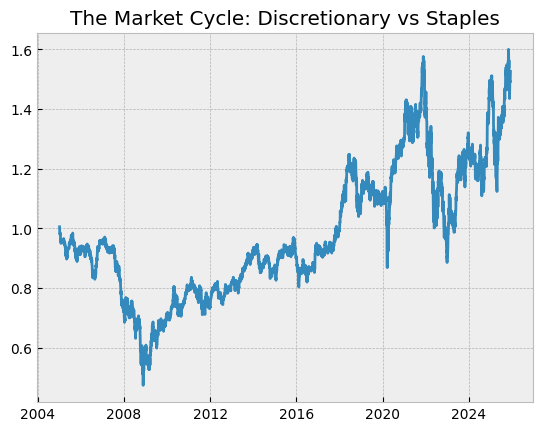

In [26]:
# Calculate the Ratio
ratio = data['XLY'] / data['XLP']

plt.plot(ratio)
plt.title('The Market Cycle: Discretionary vs Staples')
plt.show()

Building relevant features

In [27]:
window = 20


df = pd.DataFrame()
df['XLY'] = data['XLY']
df['XLP'] = data['XLP']


df['Ratio'] = df['XLY'] / df['XLP']
df['Ratio_Vol'] = df['Ratio'].pct_change().rolling(window).std()
df['Trend_Signal'] = df['Ratio'].rolling(window).mean() - df['Ratio'].rolling(50).mean()

df['Rates_Chg'] = data['^TNX'].diff(5)

delta = df['Ratio'].diff()
gain = (delta.where(delta > 0, 0)).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))



df['Z_Score'] = (df['Ratio'] - df['Ratio'].rolling(window).mean()) / df['Ratio'].rolling(window).std()

df['Target_Next_Day'] = df['Ratio'].shift(-1)

df['Target'] = np.where(df['Target_Next_Day'] > df['Ratio'], 1, 0)

df.dropna(inplace=True)
df

,XLY,XLP,Ratio,Ratio_Vol,Trend_Signal,Rates_Chg,RSI,Z_Score,Target_Next_Day,Target
Date,,,,,,,,,,
2005-03-15,13.063519,13.528749,0.965612,0.004203,-0.006786,0.167,58.543783,2.473323,0.962394,0
2005-03-16,12.986290,13.493731,0.962394,0.004057,-0.005927,0.004,59.116609,1.520646,0.959931,0
2005-03-17,12.997875,13.540424,0.959931,0.003979,-0.005103,0.011,54.964358,0.760329,0.957514,0
2005-03-18,12.923627,13.497059,0.957514,0.004008,-0.004388,-0.024,54.400325,0.089973,0.958340,1
2005-03-21,12.861758,13.420868,0.958340,0.004010,-0.003810,0.009,52.247837,0.338845,0.955698,0
...,...,...,...,...,...,...,...,...,...,...
2025-11-28,118.230003,79.370003,1.489606,0.016472,0.000925,-0.089,40.189402,-0.537519,1.491991,1
2025-12-01,118.300003,79.290001,1.491991,0.014853,-0.002386,0.033,33.787485,-0.420207,1.500825,1
2025-12-02,118.220001,78.769997,1.500825,0.014254,-0.006554,0.048,39.150623,-0.142721,1.515857,1


In [28]:
X = df[['Rates_Chg', 'Trend_Signal', 'Ratio_Vol', 'RSI', 'Z_Score']]
y = df['Target']

split = int(len(df) * 0.75)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

Standarization

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training using a soft voting classifier with random forest, gradient boost and logistic regression

In [30]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression

rf = RandomForestClassifier(n_estimators=100, max_depth=4, class_weight='balanced')
lr = LogisticRegression(class_weight='balanced') 

gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1)

ensemble = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('lr', lr)],
    voting='soft'
)

ensemble.fit(X_train_scaled, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=4)),
                             ('gb',
                              GradientBoostingClassifier(n_estimators=50)),
                             ('lr',
                              LogisticRegression(class_weight='balanced'))],
                 voting='soft')

              precision    recall  f1-score   support

           0       0.44      0.35      0.39       610
           1       0.51      0.60      0.56       694

    accuracy                           0.49      1304
   macro avg       0.48      0.48      0.47      1304
weighted avg       0.48      0.49      0.48      1304



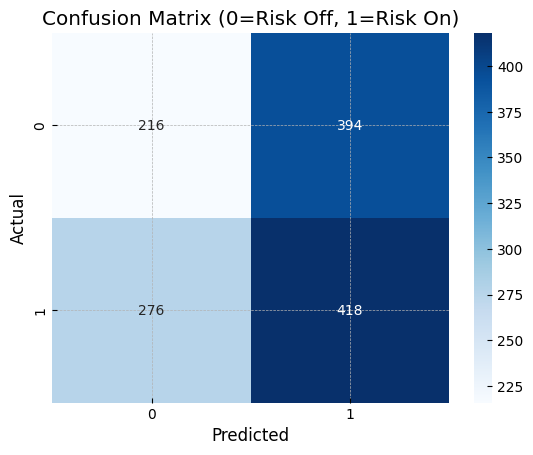

In [31]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = ensemble.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (0=Risk Off, 1=Risk On)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Calculating backtest

In [34]:
probs = ensemble.predict_proba(X_test_scaled)[:, 1]
threshold = 0.55 # The model will only make trades when he is more than 55% sure

predictions = []
for p in probs:
    if p > threshold:
        predictions.append(1)
    elif p < (1 - threshold):
        predictions.append(-1)
    else:
        predictions.append(0)

predictions = np.array(predictions[:-1])
test_returns = df[['XLY', 'XLP']].pct_change().iloc[split:]
actual_returns = test_returns.iloc[1:].copy()

spread_return = actual_returns['XLY'] - actual_returns['XLP']

strategy_returns = predictions * spread_return

Visualizing results

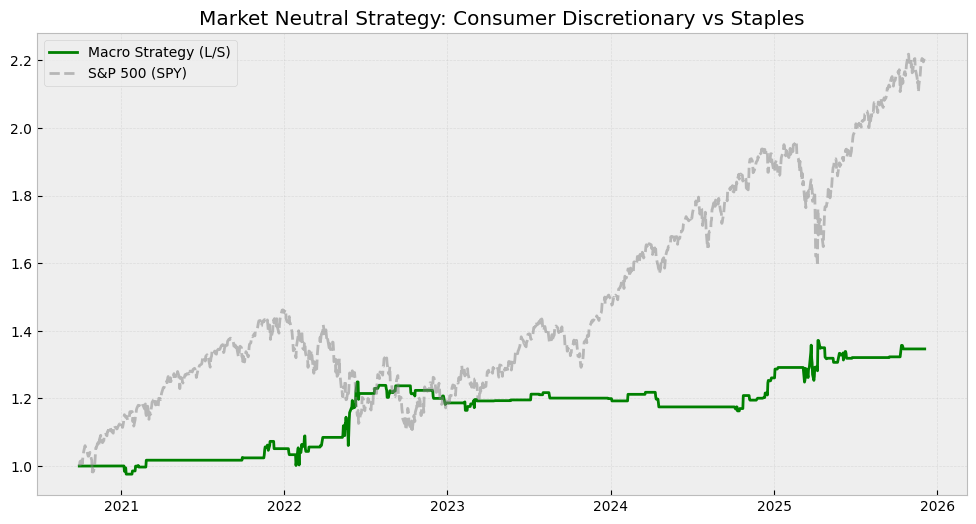

Total Strategy Return: 34.64%
Strategy Beta to Market: 0.1209


In [35]:
spy_data = yf.download('SPY', start=actual_returns.index[0], progress=False)

spy_close = spy_data['Close'].squeeze()
    
spy_ret = spy_close.pct_change().reindex(actual_returns.index).fillna(0)

cum_strategy = (1 + strategy_returns).cumprod()
cum_spy = (1 + spy_ret).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(cum_strategy, label='Macro Strategy (L/S)', color='green', linewidth=2)
plt.plot(cum_spy, label='S&P 500 (SPY)', color='gray', linestyle='--', alpha=0.5)

plt.title('Market Neutral Strategy: Consumer Discretionary vs Staples')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- BETA CALCULATION ---
covariance = np.cov(strategy_returns, spy_ret)[0][1]
variance = np.var(spy_ret)
beta = covariance / variance

print(f"Total Strategy Return: {(cum_strategy.iloc[-1]-1)*100:.2f}%")
print(f"Strategy Beta to Market: {beta:.4f}")